# Classification

,Description,Value
0,Session id,0
1,Target,label
2,Target type,Binary
3,Original data shape,"(293, 57)"
4,Transformed data shape,"(293, 57)"
5,Transformed train set shape,"(263, 57)"
6,Transformed test set shape,"(30, 57)"
7,Numeric features,56
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.6886,0.7369,0.6769,0.7035,0.6785,0.3772,0.3905,0.0320
lightgbm,Light Gradient Boosting Machine,0.6883,0.7243,0.6846,0.7043,0.6817,0.3766,0.3923,0.0370
catboost,CatBoost Classifier,0.6766,0.7307,0.6538,0.6953,0.6686,0.3532,0.3591,0.5310
xgboost,Extreme Gradient Boosting,0.6762,0.7195,0.6692,0.6826,0.6661,0.3527,0.3620,0.0300
ada,Ada Boost Classifier,0.6583,0.6874,0.6154,0.6744,0.6369,0.3165,0.3243,0.0160
rf,Random Forest Classifier,0.6426,0.6709,0.6538,0.6551,0.6432,0.2860,0.2970,0.0270
knn,K Neighbors Classifier,0.6157,0.6527,0.6154,0.6154,0.6098,0.2309,0.2337,0.0130
dt,Decision Tree Classifier,0.6044,0.6049,0.6231,0.5948,0.6034,0.2095,0.2143,0.0050
et,Extra Trees Classifier,0.6017,0.6231,0.6231,0.5936,0.6008,0.2037,0.2127,0.0230
ridge,Ridge Classifier,0.6014,0.0000,0.5846,0.6026,0.5859,0.2033,0.2079,0.0040


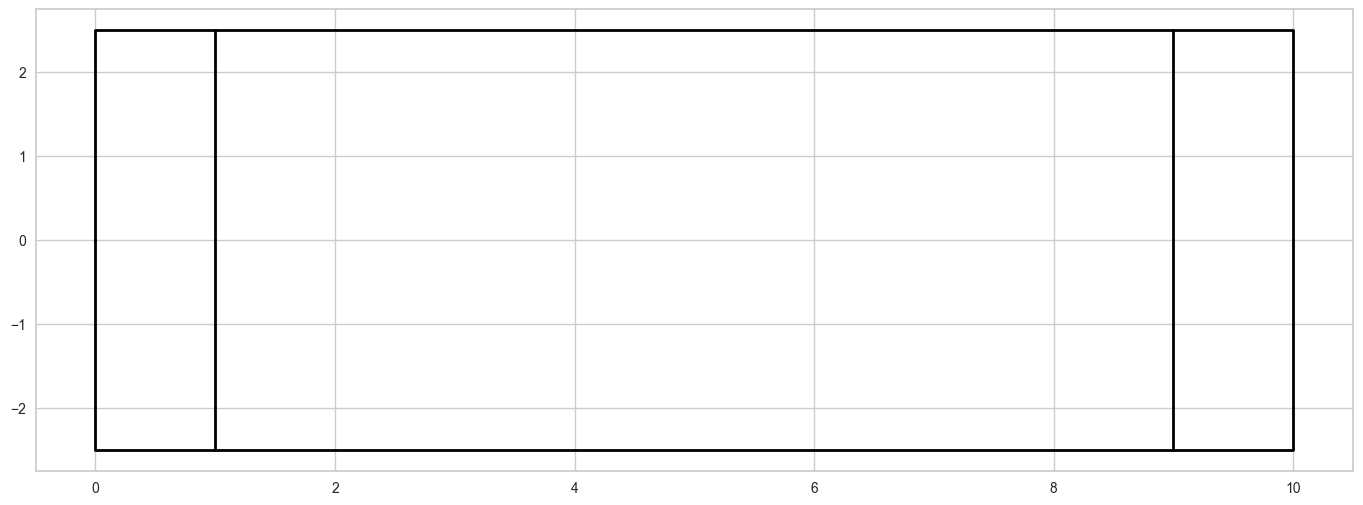

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
import numpy as np
import pandas as pd
from pycaret.classification import *

df = pd.read_excel('C:/Users/user/class_extracted.xlsx')
df = df.dropna()
df = df.reset_index(drop = True)

# classification으로 전환
label = np.where(df['Result'] == 1.0, int(1), int(0))
label = label.reshape(-1,1)

df['label'] = label
df = df.drop(['Result', 'TRVmax[kV]'], axis = 1)

setup = setup(data = df, target = 'label', session_id = 0, train_size = 0.9,)
best_model = compare_models()
evaluate_model(best_model)

# Regression

,Description,Value
0,Session id,0
1,Target,TRVmax[kV]
2,Target type,Regression
3,Original data shape,"(450, 57)"
4,Transformed data shape,"(450, 57)"
5,Transformed train set shape,"(405, 57)"
6,Transformed test set shape,"(45, 57)"
7,Numeric features,56
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,3.2351,17.1963,4.1144,0.5137,0.2791,0.2698,0.0850
gbr,Gradient Boosting Regressor,3.1946,17.6537,4.1634,0.5024,0.2770,0.2602,0.0410
et,Extra Trees Regressor,3.2798,17.6666,4.1872,0.4917,0.2810,0.2696,0.0510
lightgbm,Light Gradient Boosting Machine,3.3004,18.5902,4.2714,0.4678,0.2813,0.2610,0.0530
xgboost,Extreme Gradient Boosting,3.3502,19.2506,4.3411,0.4471,0.2909,0.2738,0.0280
ridge,Ridge Regression,3.4277,20.3864,4.4748,0.4183,0.2929,0.2768,0.3950
ada,AdaBoost Regressor,3.5883,20.5372,4.4978,0.4170,0.3123,0.3171,0.0200
br,Bayesian Ridge,3.4571,20.7737,4.5214,0.4071,0.2994,0.2828,0.0060
knn,K Neighbors Regressor,3.5013,21.0730,4.5353,0.4070,0.3015,0.2928,0.0160
lr,Linear Regression,3.6071,21.2325,4.5722,0.4012,0.3031,0.2918,0.6180


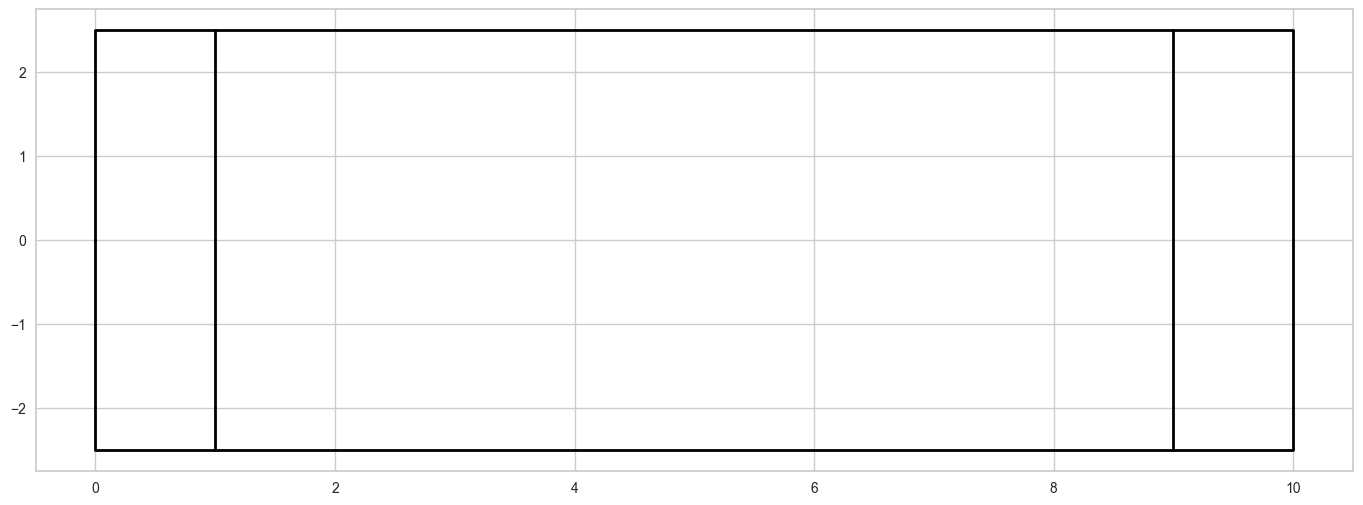

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
import numpy as np
import pandas as pd
from pycaret.regression import *

df_all = pd.read_excel('C:/Users/user/Reg_extracted.xlsx')
df_all = df_all.dropna()
df_all = df_all.reset_index(drop = True)

df_all = df_all.drop(['Time', 'Result', 'CZM', 'Test'], axis = 1)
# 첫 번째 열 이름 구하기
first_col = df_all.columns[0]

# 나머지 열 + 첫 번째 열 순서로 재배치
df_all = df_all[df_all.columns[1:].tolist() + [first_col]]
df_all

setup = setup(data = df_all, target = 'TRVmax[kV]', session_id = 0, train_size = 0.9,)
best_model = compare_models()
evaluate_model(best_model)